# Olentangy School District Salaries — EDA

Gross pay for 4,238 employees of a large Ohio school district, calendar year 2025.
Two files: one row per **employee**, and one row per **employee-role** (many staff hold
several jobs).

## What this notebook finds

1. **The payroll is bimodal, not bell-shaped.** A quarter of "employees" earn under
   $13,381 — substitutes, coaches and supplemental staff sharing a payroll with
   full-time teachers near $100k. Any single "average salary" number mixes the two.
2. **The top 25% of earners take 52% of the payroll.** Not because the top is extreme —
   the highest paid employee earns 6× the median, which is modest — but because the
   bottom half barely registers.
3. **Teachers are 51% of all payroll dollars**, more than every other role combined.
4. **Holding more jobs predicts *lower* pay, not higher.** The opposite of the obvious
   hypothesis, and the most interesting thing in the data.
5. **Contract length doesn't explain pay — role does.** Two groups sit at $224/day and
   $630/day on nearly identical contracts.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DATASET = 'robschieber/olentangy-school-district-salaries-2025'

# palette: validated categorical slots 1-3 (blue / orange / aqua) plus chart ink
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#898781', '#e1e0d9'

sns.set_theme(style='white', rc={
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.labelcolor': '#52514e', 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'font.family': 'sans-serif',
})


def _money(v, _):
    """$0 / $48k / $120M — pick the unit so axis ticks stay short."""
    if not v:
        return '$0'
    if abs(v) >= 1_000_000:
        return f'${v / 1_000_000:,.0f}M'
    if abs(v) >= 1_000:
        return f'${v / 1_000:,.0f}k'
    return f'${v:,.0f}'


MONEY = mticker.FuncFormatter(_money)


def style(ax, title=None, sub=None, xlabel=None, ylabel=None, money_x=False, money_y=False):
    """Hairline horizontal grid, no top/right spines, optional $ axis formatting."""
    if title:
        ax.set_title(title, loc='left', pad=18 if sub else 10, fontweight='bold')
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9.5, color='#52514e')
    ax.set_xlabel(xlabel or '')
    ax.set_ylabel(ylabel or '')
    ax.grid(axis='y', color=GRID, linewidth=0.8, linestyle='-')
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    if money_x:
        ax.xaxis.set_major_formatter(MONEY)
    if money_y:
        ax.yaxis.set_major_formatter(MONEY)
    return ax


def data_dir():
    """Attached Kaggle input, then a local checkout, then download via kagglehub."""
    here = Path.cwd().resolve()
    for root in [Path('/kaggle/input'), *(p / 'data' / 'kaggle' for p in (here, *here.parents))]:
        if root.exists() and any(root.glob('**/olentangy_salaries.csv')):
            return sorted(root.glob('**/olentangy_salaries.csv'))[0].parent
    import kagglehub  # only reached outside Kaggle with no local copy

    return Path(kagglehub.dataset_download(DATASET))


DATA = data_dir()
con = duckdb.connect()
con.execute(f"CREATE VIEW emp AS SELECT * FROM read_csv('{DATA / 'olentangy_salaries.csv'}')")
con.execute(f"CREATE VIEW roles AS SELECT * FROM read_csv('{DATA / 'olentangy_salary_roles.csv'}')")
print(f'loaded from {DATA}')
con.sql('SELECT count(*) AS employees, (SELECT count(*) FROM roles) AS role_rows FROM emp')

loaded from /Users/rschieber/Documents/workspace/kaggle-datasets/school-district-salaries/data/kaggle


┌───────────┬───────────┐
│ employees │ role_rows │
│   int64   │   int64   │
├───────────┼───────────┤
│      4238 │      6005 │
└───────────┴───────────┘

## 1. The payroll has two populations, not one

Start with the distribution, because it decides how every later number should be read.

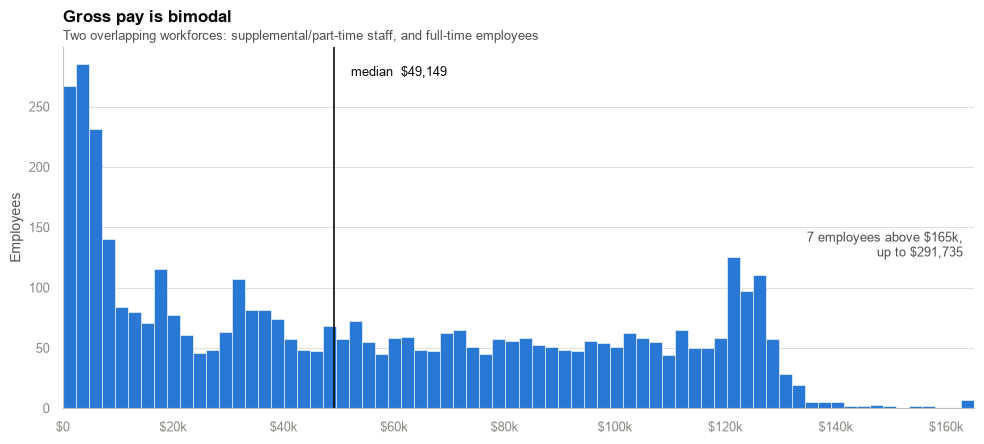

┌──────────┬───────────┬───────────┬────────────┐
│ under_5k │ under_25k │ over_100k │ median_pay │
│  int64   │   int64   │   int64   │   double   │
├──────────┼───────────┼───────────┼────────────┤
│      588 │      1435 │       944 │    49149.0 │
└──────────┴───────────┴───────────┴────────────┘

In [2]:
pay = con.sql('SELECT gross_pay FROM emp').df()['gross_pay'].astype(float)
med, top_pay = pay.median(), pay.max()
CUT = 165_000  # clip the sparse tail so the bulk is legible; the count above is annotated

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.hist(pay.clip(upper=CUT), bins=70, color=BLUE, edgecolor='white', linewidth=0.4)
ax.axvline(med, color=INK, linewidth=1.2)
ax.annotate(f'median  ${med:,.0f}', xy=(med, ax.get_ylim()[1] * 0.92),
            xytext=(12, 0), textcoords='offset points', fontsize=9.5, color=INK)
ax.annotate(f'{(pay > CUT).sum()} employees above ${CUT/1000:,.0f}k,\nup to ${top_pay:,.0f}',
            xy=(CUT, ax.get_ylim()[1] * 0.42), xytext=(-8, 0), textcoords='offset points',
            fontsize=9, color='#52514e', ha='right')
ax.set_xlim(0, CUT)
style(ax, 'Gross pay is bimodal',
      'Two overlapping workforces: supplemental/part-time staff, and full-time employees',
      ylabel='Employees', money_x=True)
plt.tight_layout()
plt.show()

con.sql('''
    SELECT count(*) FILTER (gross_pay < 5000)   AS under_5k,
           count(*) FILTER (gross_pay < 25000)  AS under_25k,
           count(*) FILTER (gross_pay >= 100000) AS over_100k,
           round(median(gross_pay))              AS median_pay
    FROM emp
''')

**The spike at zero is the story.** 588 people earned under $5,000 and 1,435 under $25,000 —
a third of the "workforce." These are substitutes, athletic coaches and supplemental-duty
staff, and they share a payroll file with teachers earning $100k+.

The median of $49,149 sits in the *valley between the two humps*, describing almost nobody.
This is the single most important thing to know before quoting any average from this data.

## 2. How concentrated is the payroll?

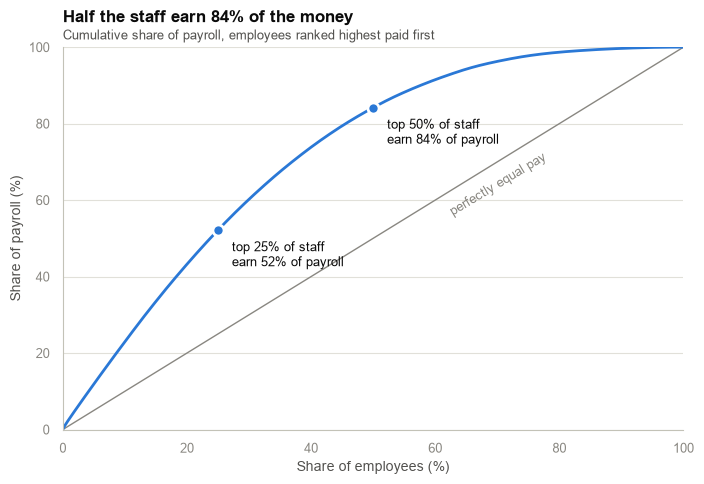

In [3]:
lorenz = con.sql('''
    WITH r AS (SELECT gross_pay, row_number() OVER (ORDER BY gross_pay DESC) AS rn FROM emp)
    SELECT 100.0 * rn / (SELECT count(*) FROM emp)                      AS pct_employees,
           100.0 * sum(gross_pay) OVER (ORDER BY rn)
                 / (SELECT sum(gross_pay) FROM emp)                     AS pct_payroll
    FROM r ORDER BY rn
''').df()

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot([0, 100], [0, 100], color=MUTED, linewidth=1, zorder=1)
ax.text(62, 56, 'perfectly equal pay', color=MUTED, fontsize=9, rotation=31)
ax.plot(lorenz['pct_employees'], lorenz['pct_payroll'], color=BLUE, linewidth=2, zorder=2)

for mark in (25, 50):
    y = lorenz.loc[(lorenz['pct_employees'] - mark).abs().idxmin(), 'pct_payroll']
    ax.plot([mark], [y], 'o', color=BLUE, markersize=8,
            markeredgecolor='white', markeredgewidth=2, zorder=3)
    ax.annotate(f'top {mark}% of staff\nearn {y:.0f}% of payroll', xy=(mark, y),
                xytext=(10, -26), textcoords='offset points', fontsize=9.5, color=INK)

ax.set_xlim(0, 100); ax.set_ylim(0, 100)
style(ax, 'Half the staff earn 84% of the money',
      'Cumulative share of payroll, employees ranked highest paid first',
      xlabel='Share of employees (%)', ylabel='Share of payroll (%)')
plt.tight_layout()
plt.show()

The curve bows hard, but **not because the top is extreme.** The highest-paid employee
(the superintendent, $291,735) earns about 6× the median — unremarkable next to private
sector or university pay scales, and the top 1% take only 2.7% of payroll.

The bow comes from the *bottom*: the 2,100 part-time and supplemental staff seen in chart 1
split 16% of the money between them. This is a chart about part-time work, not executive pay —
a good reminder that a Gini-shaped curve doesn't always mean what it looks like.

## 3. Where the money actually goes

Headcount and payroll dollars rank roles very differently, so plot them as two panels
against a shared role order — never as two y-axes on one chart.

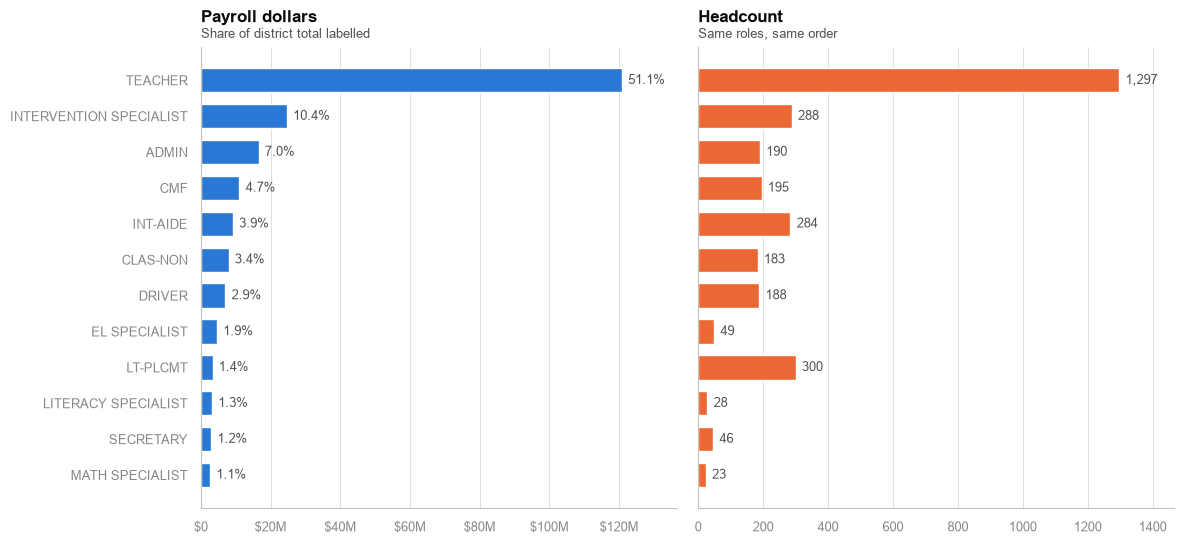

,role,employees,total_pay,pct_payroll
0,TEACHER,1297,120820403.3,51.1
1,INTERVENTION SPECIALIST,288,24648695.1,10.4
2,ADMIN,190,16566112.3,7.0
3,CMF,195,11032439.2,4.7
4,INT-AIDE,284,9154196.0,3.9
5,CLAS-NON,183,7929278.8,3.4
6,DRIVER,188,6957983.9,2.9
7,EL SPECIALIST,49,4586312.2,1.9
8,LT-PLCMT,300,3307527.4,1.4
9,LITERACY SPECIALIST,28,3153508.7,1.3


In [4]:
top = con.sql('''
    SELECT r.role_base                                   AS role,
           count(*)                                      AS employees,
           sum(e.gross_pay)                              AS total_pay,
           100.0 * sum(e.gross_pay)
                 / (SELECT sum(gross_pay) FROM emp)      AS pct_payroll
    FROM roles r JOIN emp e USING (employee_id)
    WHERE r.role_seq = 1
    GROUP BY 1 ORDER BY total_pay DESC LIMIT 12
''').df().iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharey=True)

axes[0].barh(top['role'], top['total_pay'].astype(float), color=BLUE, height=0.68)
style(axes[0], 'Payroll dollars', 'Share of district total labelled', money_x=True)
for y, (v, p) in enumerate(zip(top['total_pay'].astype(float), top['pct_payroll'])):
    axes[0].text(v + top['total_pay'].max() * 0.015, y, f'{p:.1f}%',
                 va='center', fontsize=9, color='#52514e')

axes[1].barh(top['role'], top['employees'], color=ORANGE, height=0.68)
style(axes[1], 'Headcount', 'Same roles, same order')
for y, v in enumerate(top['employees']):
    axes[1].text(v + top['employees'].max() * 0.015, y, f'{v:,}',
                 va='center', fontsize=9, color='#52514e')

for ax in axes:
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.margins(x=0.13)
plt.tight_layout()
plt.show()

top.iloc[::-1][['role', 'employees', 'total_pay', 'pct_payroll']].round(1)

**Teachers alone are 51.1% of every payroll dollar** — more than the other eleven roles
on this chart combined.

The two panels disagree in instructive places. `LT-PLCMT` and `INT-AIDE` have headcounts
rivalling `ADMIN` but a fraction of the dollars, because they're part-time roles.
`ADMIN` inverts it: 190 people, 7% of payroll.

Note `CMF` and `CLAS-NON` sitting in the top six. Those are undocumented district payroll
codes — together roughly $19M, and nobody outside the district's payroll office appears to
have published what they mean.

## 4. What does a teacher actually earn?

Filter to people whose *only* role is `TEACHER`, so coaching stipends and second jobs
don't contaminate the number.

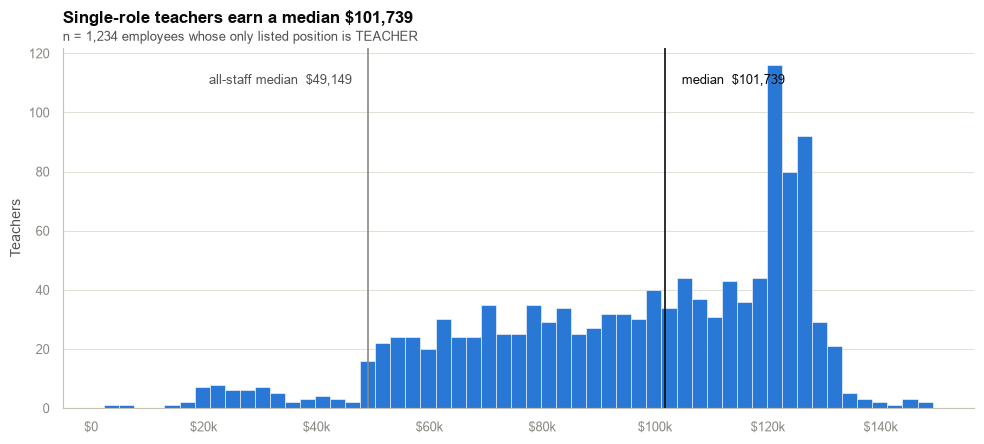

,gross_pay
count,1234.0
mean,95756.0
std,28190.0
min,2318.0
25%,74856.0
50%,101739.0
75%,121023.0
max,149147.0


In [5]:
teachers = con.sql('''
    WITH k AS (SELECT employee_id, count(*) AS n FROM roles GROUP BY 1)
    SELECT e.gross_pay FROM roles r JOIN k USING (employee_id) JOIN emp e USING (employee_id)
    WHERE r.role = 'TEACHER' AND k.n = 1
''').df()['gross_pay'].astype(float)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.hist(teachers, bins=55, color=BLUE, edgecolor='white', linewidth=0.4)
for label, v, off in [('median', teachers.median(), 12), ('all-staff median', med, -12)]:
    ax.axvline(v, color=INK if label == 'median' else MUTED, linewidth=1.2)
    ax.annotate(f'{label}  ${v:,.0f}', xy=(v, ax.get_ylim()[1] * 0.9),
                xytext=(off, 0), textcoords='offset points', fontsize=9.5,
                color=INK if label == 'median' else '#52514e',
                ha='left' if off > 0 else 'right')
style(ax, f'Single-role teachers earn a median ${teachers.median():,.0f}',
      f'n = {len(teachers):,} employees whose only listed position is TEACHER',
      ylabel='Teachers', money_x=True)
plt.tight_layout()
plt.show()

teachers.describe().round(0).to_frame('gross_pay')

A very different shape from the district as a whole: broad, roughly symmetric, spanning
**$74.9k to $121.0k across the interquartile range** — the signature of a step-and-column
salary schedule, where pay is a published function of years served and degree held rather
than of negotiation.

There is still a thin left tail down to $2,318 — teachers who started or left mid-year.
The district median of $49,149 is less than half the single-role teacher median of
$101,739, which shows how heavily the part-time population drags the headline figure down.

## 5. The surprise: more jobs, less money

39% of employees hold more than one position. The obvious hypothesis is that a second job —
coaching, tutoring, driving a route — stacks onto a salary. Test it.

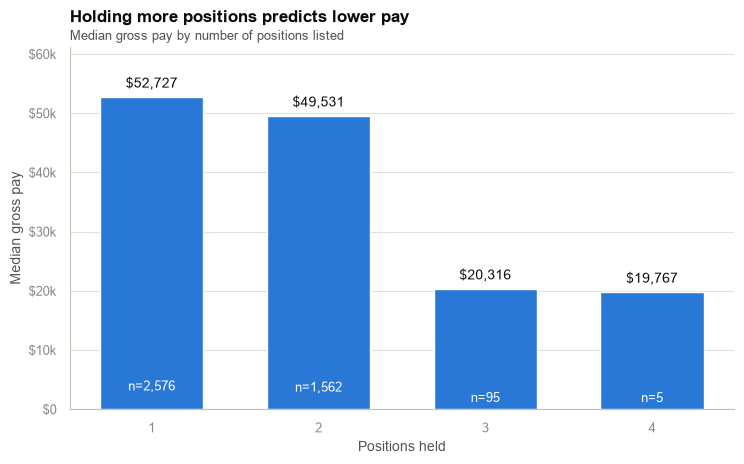

┌───────────────────┬───────────┐
│     role_base     │ employees │
│      varchar      │   int64   │
├───────────────────┼───────────┤
│ SUB-CLAS          │        49 │
│ INT-AIDE          │        44 │
│ LT-PLCMT          │        43 │
│ INTERVENTION AIDE │        39 │
│ FOOD-SVC          │        26 │
│ FOOD SVC WORKER   │        21 │
└───────────────────┴───────────┘

In [6]:
byroles = con.sql('''
    WITH k AS (SELECT employee_id, count(*) AS n_roles FROM roles GROUP BY 1)
    SELECT k.n_roles, count(*) AS employees, median(e.gross_pay) AS median_pay
    FROM k JOIN emp e USING (employee_id) GROUP BY 1 ORDER BY 1
''').df()

fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.bar(byroles['n_roles'].astype(str), byroles['median_pay'].astype(float),
       color=BLUE, width=0.62)
for x, (v, n) in enumerate(zip(byroles['median_pay'].astype(float), byroles['employees'])):
    ax.text(x, v + 1600, f'${v:,.0f}', ha='center', fontsize=10, color=INK)
    ax.text(x, v * 0.06, f'n={n:,}', ha='center', fontsize=9, color='white')
style(ax, 'Holding more positions predicts lower pay',
      'Median gross pay by number of positions listed',
      xlabel='Positions held', ylabel='Median gross pay', money_y=True)
ax.margins(y=0.16)
plt.tight_layout()
plt.show()

con.sql('''
    WITH k AS (SELECT employee_id, count(*) AS n FROM roles GROUP BY 1)
    SELECT r.role_base, count(*) AS employees
    FROM roles r JOIN k USING (employee_id)
    WHERE k.n >= 3 GROUP BY 1 ORDER BY employees DESC LIMIT 6
''')

**The hypothesis is wrong, and backwards.** Median pay *falls* as positions accumulate:
$52,727 at one position, $49,531 at two, then a cliff to $20,316 at three and $19,767 at four.

The table underneath explains it. People holding 3+ positions are overwhelmingly
`SUB-CLAS` (substitutes), `INT-AIDE`, `LT-PLCMT` and `FOOD-SVC` — **not** teachers adding a
coaching stipend. Multiple roles here are a marker of *piecing together part-time work*,
not of moonlighting on top of a salary.

This is a textbook confound: `n_roles` looks like a measure of extra work, but it's really
proxying for employment category. Any model using it needs to control for role, or it will
learn exactly the wrong sign.

## 6. Contract length doesn't explain pay

176 employees have a contract-day count published in their role string
(`SECRETARY 260` = 260 days/year). Does a longer contract mean more money?

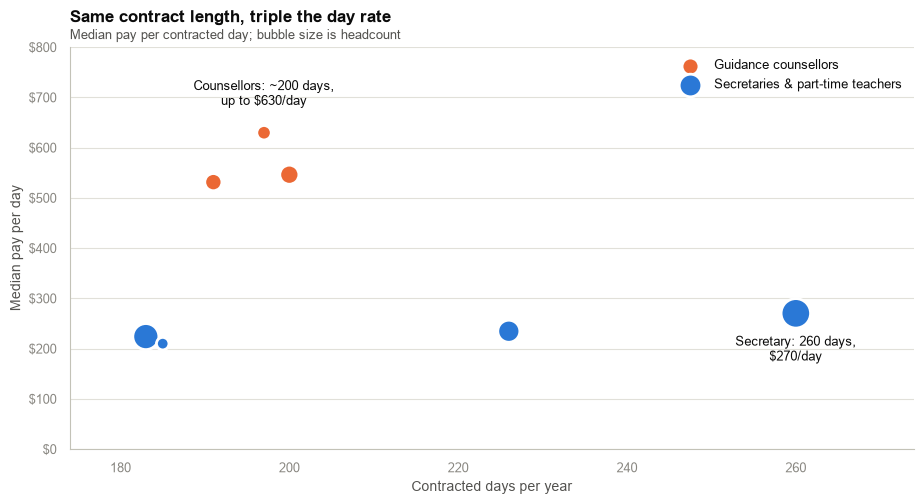

,contract_days,role_base,employees,median_pay,per_day
0,183,SECRETARY,39,40979.0,224.0
1,185,TEACHER PT,9,38823.0,210.0
2,191,GUIDANCE COUNSELOR ES,17,101480.0,531.0
3,197,GUIDANCE COUNSELOR MS,12,124039.0,630.0
4,200,GUIDANCE COUNSELOR HS,21,109220.0,546.0
5,226,SECRETARY,28,53007.0,235.0
6,260,SECRETARY,50,70244.0,270.0


In [7]:
days = con.sql('''
    SELECT r.contract_days, r.role_base, count(*) AS employees,
           median(e.gross_pay)                      AS median_pay,
           median(e.gross_pay) / r.contract_days    AS per_day
    FROM roles r JOIN emp e USING (employee_id)
    WHERE r.contract_days IS NOT NULL
    GROUP BY 1, 2 ORDER BY 1
''').df()
days['group'] = days['role_base'].str.startswith('GUIDANCE').map(
    {True: 'Guidance counsellors', False: 'Secretaries & part-time teachers'})

fig, ax = plt.subplots(figsize=(9.4, 5.2))
for name, color in [('Guidance counsellors', ORANGE), ('Secretaries & part-time teachers', BLUE)]:
    g = days[days['group'] == name]
    ax.scatter(g['contract_days'], g['per_day'].astype(float), s=g['employees'] * 9,
               color=color, label=name, edgecolor='white', linewidth=2, zorder=3)

# label only the two points that carry the argument; the table below has the rest
for days_x, dy, text in [
    (197, 20, 'Counsellors: ~200 days,\nup to $630/day'),
    (260, -34, 'Secretary: 260 days,\n$270/day'),
]:
    row = days.loc[days['contract_days'] == days_x].iloc[0]
    ax.annotate(text, xy=(days_x, float(row['per_day'])), xytext=(0, dy),
                textcoords='offset points', ha='center', fontsize=9, color=INK)

ax.legend(frameon=False, loc='upper right', fontsize=9.5)
ax.set_ylim(0, 800)
ax.set_xlim(174, 274)
style(ax, 'Same contract length, triple the day rate',
      'Median pay per contracted day; bubble size is headcount',
      xlabel='Contracted days per year', ylabel='Median pay per day')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

days[['contract_days', 'role_base', 'employees', 'median_pay', 'per_day']].round(0)

**Two clean clusters, and contract length isn't what separates them.** Guidance counsellors
on 191–200 day contracts earn $531–$630 per day; secretaries on 183–260 days earn $224–$270.
The counsellors work *fewer* days than a 260-day secretary and earn nearly triple per day.

*Within* a role the relationship does hold and is almost linear — secretaries go
$224 → $235 → $270 per day as contracts stretch 183 → 226 → 260 days, which is what you'd
expect if longer contracts also track seniority.

So `contract_days` is a useful feature only in interaction with role, never on its own.
Fitting pay on contract days alone across the whole dataset would produce a near-flat,
meaningless line.

## Where to take this next

- **Build a job-family taxonomy.** The 88 roles are the dataset's biggest open problem.
  `CMF`, `CLAS-NON`, `LT-PLCMT` and `UNIV-PLA` cover ~573 employees and have no published
  key — the dataset deliberately ships them un-grouped rather than guessing.
- **Separate the two populations first.** Almost every question here gets a sharper answer
  after splitting full-time from supplemental staff. There's no FTE column, so you'll need
  a threshold or a mixture model — and your choice will drive the result.
- **Mind the `-0` role suffix.** 59 employees carry a `TEACHER-0`-style line with much lower
  pay. Decide deliberately whether to include them before computing any average.
- **Compare districts.** Central Ohio districts publish payroll in the same format, so the
  same parsing works on neighbours.

**Caveats that matter:** `gross_pay` includes overtime, stipends, holiday and accrued time —
it is not contracted salary. There's no FTE, tenure or degree field, so per-hour
normalisation isn't possible. Data compiled by *The Columbus Dispatch* from public records;
their editors note AI tooling was used in cleaning it.